In [62]:
import torch
import torch.nn as nn
import numpy as np
import argparse
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as ps

from modules import SAB, ISAB, MAB, PMA
from typing import Optional
from torch.utils.data import TensorDataset, DataLoader, random_split
from pathlib import Path
from train_sm import MakeDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


['outputIdx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'ele_xy', 'jagged_lengths', 'neighbour_indices', 'init_energies', 'acc_don_int', 'acc_acc_int', 'rand_energies', 'rate_prefactors']


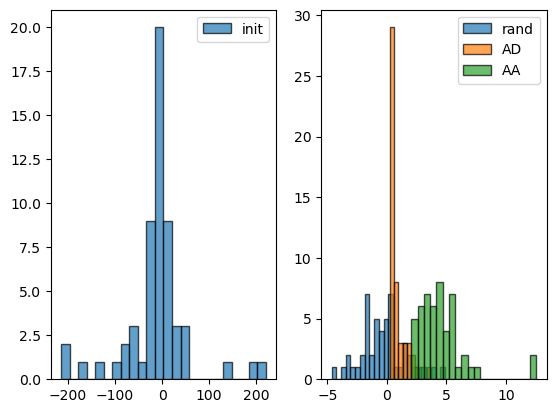

In [30]:
set_example = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_n_a=50//batch_0.npz")
print(set_example.files)
set_rand_en = set_example['rand_energies']
set_AD_int = set_example['acc_don_int']
set_AA_int = set_example['acc_acc_int']
set_init_en = set_example['init_energies'][0]

fig, ax = plt.subplots(ncols=2)

for a in ax:
    a.set_aspect("auto")
    
ax[0].hist(set_init_en, bins=24, ec="k", alpha=.7, label="init")
ax[0].legend()
ax[1].hist(set_rand_en, bins=24, ec="k", alpha=.7, label="rand")
ax[1].hist(set_AD_int, bins=10, ec="k", alpha=.7, label="AD")
ax[1].hist(set_AA_int, bins=20, ec="k", alpha=.7, label="AA")
ax[1].legend()

['outputIdx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat']
-184.09009646295766
143.08615259637278


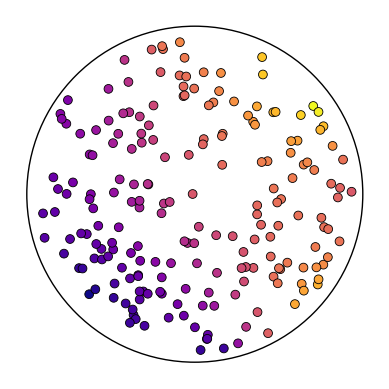

In [109]:
graph_data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/graph_data/graph_batch.npz")
print(graph_data.files)

idx = np.random.randint(0, graph_data['acc_xy'].shape[0])
acc_pos_0 = graph_data['acc_xy'][idx]
init_en_0 = graph_data['init_en'][idx]

en_min = init_en_0[:200].min()
en_max = init_en_0[:200].max()

print(f"{en_min}")
print(f"{en_max}")

norm = mcolors.Normalize(vmin=en_min, vmax=en_max)
cm = plt.get_cmap('plasma')
clrs = init_en_0[:200]

radius = 150
radius_sc = radius / np.sqrt(np.pi*radius**2 / 200)

plot_kwargs = {
    "s": 40,
    "ec": 'k',
    "linewidth":0.6,
    "alpha": 1.0,
    "cmap": cm,
    "norm": norm,
    "c": clrs,
}

fig, ax = plt.subplots()
sc = ax.scatter(*acc_pos_0.T, **plot_kwargs)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
ax.add_patch(ps.Circle(xy=(0,0), radius=radius_sc + 0.5, fill=None))
#plt.colorbar(sc)

0


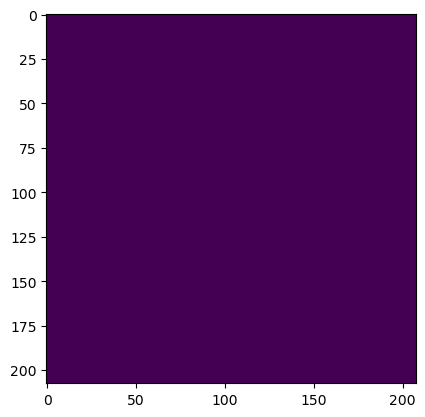

In [117]:
print(graph_data['adj_mat'][idx].sum())
plt.imshow(graph_data['adj_mat'][idx])